A Business Analytics Model On a Dataset using the Random Forest Classifier

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

IMPORTING THE DATASET 

In [2]:
df = pd.read_csv('SampleSuperstore.csv')


DATA OVERVIEW AND DESCRIPTION

In [3]:
print(df.isnull().sum()) #identifying missing values


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [4]:
df. head(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.tail(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


DATA PREPARATION STEPS


In [6]:
# Drop Customer_ID as it is not useful for modeling
df= df.drop(columns=['Postal Code'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Region        9994 non-null   object 
 6   Category      9994 non-null   object 
 7   Sub-Category  9994 non-null   object 
 8   Sales         9994 non-null   float64
 9   Quantity      9994 non-null   int64  
 10  Discount      9994 non-null   float64
 11  Profit        9994 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 937.1+ KB


In [8]:
df['Discount'].unique()


array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save the encoder for decoding later


DATA TRANSFORMATION

In [11]:
#Scale numerical features
scaler = StandardScaler()
df[['Sales','Quantity', 'Category', 'Sub-Category','Ship Mode', 'Country', 'Region', 'State', 'City','Segment', 'Discount']] = scaler.fit_transform(df[['Sales','Quantity', 'Category', 'Sub-Category','Ship Mode', 'Country', 'Region', 'State', 'City','Segment', 'Discount']])

In [463]:
print("Profit unique values:", df["Profit"].unique())
print("Sub-Category unique values:", df["Sub-Category"].unique())
print("Category unique values:", df["Category"].unique())


Profit unique values: [5740 6962 3301 ... 4520 2684 6270]
Sub-Category unique values: [-0.71081548 -0.51284179  0.47702666  1.6648688   1.26892142  0.27905297
 -1.10676286  1.07094773 -0.90878917 -1.30473655  0.87297404 -1.50271024
 -0.11689441  0.08107928  1.46689511  0.67500035 -0.3148681 ]
Category unique values: [-1.54497781  0.04355184  1.6320815 ]


Correlation Matrix (Raw):
               Ship Mode   Segment  Country      City     State    Region  \
Ship Mode      1.000000 -0.004527      NaN -0.003602  0.011865 -0.023809   
Segment       -0.004527  1.000000      NaN  0.005505 -0.002567 -0.005560   
Country             NaN       NaN      NaN       NaN       NaN       NaN   
City          -0.003602  0.005505      NaN  1.000000  0.009805  0.282255   
State          0.011865 -0.002567      NaN  0.009805  1.000000 -0.444400   
Region        -0.023809 -0.005560      NaN  0.282255 -0.444400  1.000000   
Category      -0.004129  0.010123      NaN  0.013736  0.006285 -0.005148   
Sub-Category  -0.003275  0.010943      NaN -0.005966 -0.002061  0.009112   
Sales         -0.001887  0.010866      NaN  0.005592  0.004015  0.004216   
Quantity       0.022440  0.008130      NaN -0.000929 -0.000836  0.013506   
Discount      -0.000436 -0.016679      NaN -0.151914  0.162552 -0.212769   
Profit        -0.010696  0.021213      NaN  0.089008 -0.11795

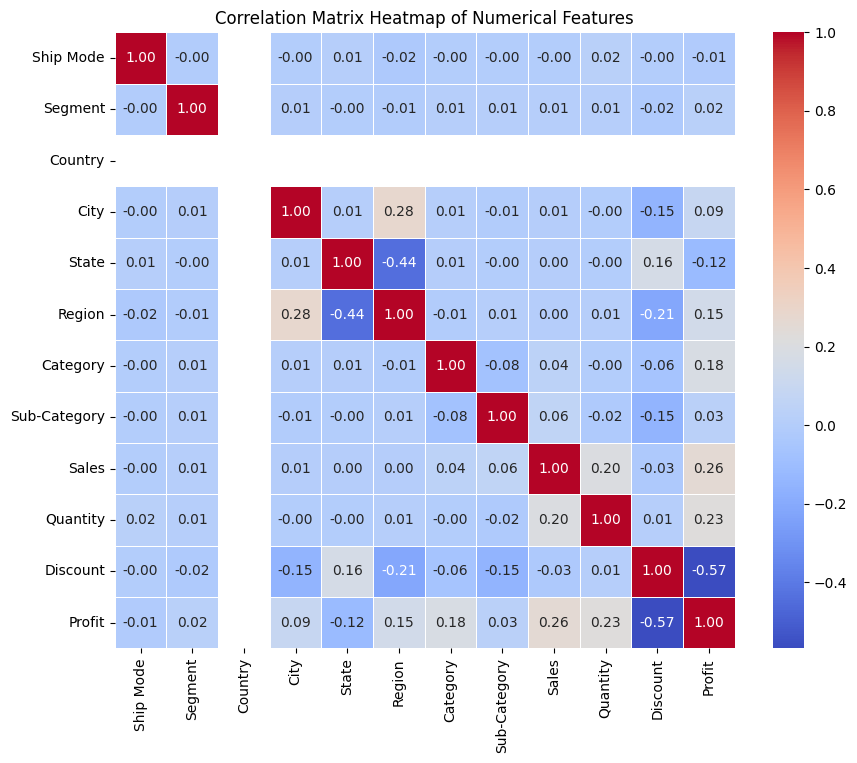

In [464]:
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Print the correlation matrix
print("Correlation Matrix (Raw):\n", correlation_matrix)

plt.figure(figsize=(10, 8)) # Adjust size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap of Numerical Features')
plt.show()

In [465]:
# Splitting the data into features and target
X = df.drop(columns=['Profit'])
# If 'Profit' is continuous, bin it into 3 classes
y= pd.cut(df["Profit"], bins=3, labels=["Low", "Medium", "High"])


In [466]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [467]:
#Building and training the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Model Evaluation

In [478]:
#Evaluating the model
predictions = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

        High       0.89      0.91      0.90       602
         Low       0.90      0.84      0.87       609
      Medium       0.87      0.89      0.88       788

    accuracy                           0.88      1999
   macro avg       0.88      0.88      0.88      1999
weighted avg       0.88      0.88      0.88      1999



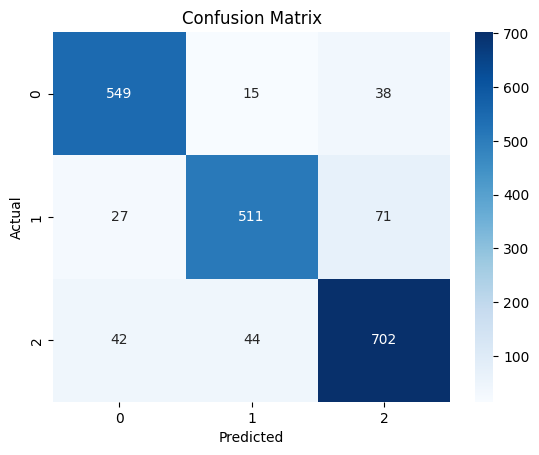

In [469]:


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




In [470]:
print(np.unique(y_test))


['High' 'Low' 'Medium']


Checking for Accuracy

In [471]:
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr', labels=model.classes_)
print(f"AUC-ROC Score: {roc_auc:.2f}")


AUC-ROC Score: 0.97


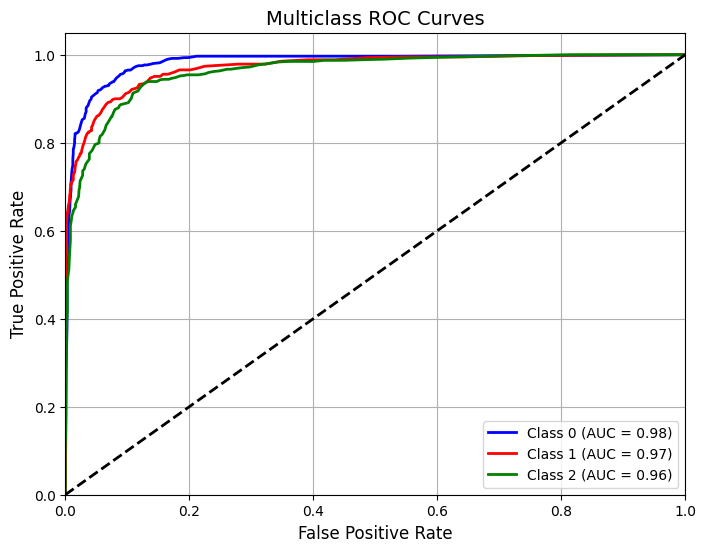

In [472]:
# Number of classes
n_classes = len(np.unique(y_test))

# Binarize the output
y_test_bin = label_binarize(y_test, classes=model.classes_)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], model.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multiclass ROC Curves', fontsize=14)
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [473]:

# Creating a list of dictionaries for each row of the report
report_data = [
    {"Class": "High", "Precision": 0.89, "Recall": 0.91, "F1-Score": 0.90, "Support": 602},
    {"Class": "Low", "Precision": 0.89, "Recall": 0.84, "F1-Score": 0.87, "Support": 609},
    {"Class": "Medium", "Precision": 0.87, "Recall": 0.89, "F1-Score": 0.88, "Support": 788},
    {"Class": "Accuracy", "Precision": 0.88, "Recall": None, "F1-Score": None, "Support": 1999},
    {"Class": "Macro Avg", "Precision": 0.88, "Recall": 0.88, "F1-Score": 0.88, "Support": 1999},
    {"Class": "Weighted Avg", "Precision": 0.88, "Recall": 0.88, "F1-Score": 0.88, "Support": 1999},
]

# Creating the DataFrame
df_report = pd.DataFrame(report_data)

# setting the index to the "Class" column for a neater look
df_report.set_index("Class", inplace=True)

# Print the DataFrame
print(df_report)
df_reportt = pd.DataFrame(df_report)
df_reportt.to_csv("classification_report3.csv", index=False)  # Export for Power BI


              Precision  Recall  F1-Score  Support
Class                                             
High               0.89    0.91      0.90      602
Low                0.89    0.84      0.87      609
Medium             0.87    0.89      0.88      788
Accuracy           0.88     NaN       NaN     1999
Macro Avg          0.88    0.88      0.88     1999
Weighted Avg       0.88    0.88      0.88     1999


In [475]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ----------------------------
# Part 1: Exporting ROC Curve Data
# ----------------------------

# Assuming that y_test and model are already defined:
# Determine the number of unique classes in y_test
n_classes = len(np.unique(y_test))

# Binarize the output (required for multiclass ROC computation)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# List to hold ROC data for each class
roc_data_list = []

# Loop through each class and compute the ROC curve data
for i in range(n_classes):
    # Calculate false positive rate, true positive rate, and thresholds for the i-th class
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], model.predict_proba(X_test)[:, i])
    auc_val = auc(fpr, tpr)
    
    # Create a DataFrame for the ROC curve of class i
    df_roc = pd.DataFrame({
        'Class': i,
        'FPR': fpr,
        'TPR': tpr,
        'Threshold': thresholds
    })
    # Add a column for AUC (same value repeated for all rows of this class)
    df_roc['AUC'] = auc_val
    
    # Append this class’s ROC data to the list
    roc_data_list.append(df_roc)

# Concatenate the ROC data from all classes into one DataFrame
roc_df = pd.concat(roc_data_list, ignore_index=True)

# Export the ROC curve data to a CSV file
roc_df.to_csv("roc_curve_data3.csv", index=False)
print("ROC curve data exported to 'roc_curve_data.csv'")

# ----------------------------
# Part 2: Exporting Feature Importance Data
# ----------------------------

# Assuming that X_test (or X_train) is a DataFrame and the model is a RandomForestClassifier
features = X_test.columns  # or use X_train.columns if preferred
importances = model.feature_importances_

# Create a DataFrame containing feature names and their corresponding importance scores
feat_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sorting the features in descending order of importance
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

# Exporting the feature importance data to a CSV file
feat_importance_df.to_csv("feature_importance3.csv", index=False)
print("Feature importance data exported to 'feature_importance.csv'")


c:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


ROC curve data exported to 'roc_curve_data.csv'
Feature importance data exported to 'feature_importance.csv'


In [476]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'encoders.pkl')

['encoders.pkl']